# Sumativa 3 — Modelamiento Predictivo Integrado
**MCDI501 · Grupo 4 · Bank Marketing UCI**

Evaluación Sumativa 3 (Fase 4: Presentación y comunicación). Todas las decisiones metodológicas se fundamentan explícitamente en los resultados de S1 (análisis exploratorio e inferencial) y S2 (validación mediante remuestreo y simulación), evidenciando la progresión S1 → S2 → S3.

## §0 — Configuración global

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score, accuracy_score,
    precision_score, recall_score, f1_score
)
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
plt.rcParams.update({'figure.dpi': 110,
                     'axes.spines.top': False,
                     'axes.spines.right': False})

# Deteccion dinamica de la raiz del proyecto
raiz = Path().resolve()
for _ in range(6):
    if (raiz / 'data').exists():
        break
    raiz = raiz.parent
RUTA_CSV = raiz / 'data' / 'raw' / 'bank-additional' / 'bank-additional-full.csv'

df_raw = pd.read_csv(RUTA_CSV, sep=';')
df_raw['y_bin'] = (df_raw['y'] == 'yes').astype(int)
print(f'Dataset cargado: {df_raw.shape}')
print(f'Tasa de suscripcion: {df_raw["y_bin"].mean():.4f} '
      f'({df_raw["y_bin"].sum():,} yes / {(df_raw["y_bin"]==0).sum():,} no)')
print(f'Columnas: {list(df_raw.columns)}')

Dataset cargado: (41188, 22)
Tasa de suscripcion: 0.1127 (4,640 yes / 36,548 no)
Columnas: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y', 'y_bin']


## §1 — Manejo inteligente de datos faltantes

### 1.1 Referencia al analisis de S1

El dataset Bank Marketing UCI **no contiene valores NaN reales** (confirmado en S1). Los datos faltantes se codifican como la cadena `'unknown'` en variables categoricas, y como el valor centinela `999` en la variable numerica `pdays` (indica que el cliente no fue contactado en campanas anteriores).

**Patron de faltantes identificado en S1:**

| Variable | N unknowns | % | Tipo | Patron probable |
|---|---|---|---|---|
| `default` | 8.597 | 20.9 % | Categorica | MAR — clientes con credito en mora pueden negarse a responder |
| `education` | 1.731 | 4.2 % | Categorica | MAR — correlaciona con `job` y `age` |
| `housing` | 990 | 2.4 % | Categorica | MAR — relacionada con `loan` |
| `loan` | 990 | 2.4 % | Categorica | MAR — relacionada con `housing` |
| `job` | 330 | 0.8 % | Categorica | MAR — correlaciona con `education` |
| `marital` | 80 | 0.2 % | Categorica | MCAR — porcentaje marginal |
| `pdays` (= 999) | 39.673 | 96.3 % | Numerica centinela | No es faltante real: indica ausencia de contacto previo |

**Decision sobre `pdays`:** recodificado a variable binaria `contactado_previo` (1 si pdays != 999), tal como se hizo en la Formativa 2. No se imputa porque 999 no es un valor faltante sino una categoria operacional del dataset.

**Variables seleccionadas como features (S1+S2):** `euribor3m`, `poutcome_enc`, `previous`, `age`, `contactado_previo` — ninguna de ellas presenta unknowns. Las variables con unknowns (`default`, `education`, `housing`, `loan`, `job`, `marital`) no forman parte del espacio de features validado, pero el tamano muestral resultante de cada estrategia de imputacion **si afecta** el entrenamiento del modelo final.

In [2]:
# Reproducir hallazgos de S1
print('=== Valores NaN reales ===')
nans = df_raw.isnull().sum()
print(nans[nans > 0].to_string() if nans.any() else 'Ninguno')

print('\n=== Frecuencia de unknown por variable categorica ===')
cat_cols = df_raw.select_dtypes(include='object').columns.drop('y')
unk = {c: (df_raw[c] == 'unknown').sum() for c in cat_cols if (df_raw[c] == 'unknown').any()}
for col, n in sorted(unk.items(), key=lambda x: -x[1]):
    print(f'  {col:20s}: {n:5,} ({n/len(df_raw)*100:.1f}%)')

n_con_unknown = (df_raw[list(unk.keys())] == 'unknown').any(axis=1).sum()
print(f'\nObservaciones con al menos un unknown: {n_con_unknown:,} '
      f'({n_con_unknown/len(df_raw)*100:.1f}%)')

=== Valores NaN reales ===
Ninguno

=== Frecuencia de unknown por variable categorica ===
  default             : 8,597 (20.9%)
  education           : 1,731 (4.2%)
  housing             :   990 (2.4%)
  loan                :   990 (2.4%)
  job                 :   330 (0.8%)
  marital             :    80 (0.2%)

Observaciones con al menos un unknown: 10,700 (26.0%)


### 1.2 Imputacion mediante regresion

Para las variables categoricas con unknowns, se utiliza **regresion logistica multinomial** (equivalente a la regresion lineal para variables continuas, pero adaptada a variables categoricas) con 3 a 5 predictores seleccionados desde la matriz de correlaciones de S1 y validados en S2.

**Estrategia de predictores por variable:**

| Variable a imputar | Predictores usados | Justificacion (S1/S2) |
|---|---|---|
| `job` | `age`, `education`, `marital` | Correlacion con edad y nivel educativo (S1) |
| `education` | `job`, `age`, `marital` | Alta dependencia con ocupacion (S1) |
| `marital` | `age`, `education`, `job` | Correlacion con edad (S1) |
| `housing` | `loan`, `job`, `age`, `marital` | Asociacion entre productos financieros (S1) |
| `loan` | `housing`, `job`, `age`, `marital` | Idem housing |
| `default` | `job`, `age`, `housing`, `loan`, `education` | Variable con mayor proporcion de unknowns (20.9 %) |

> **Nota:** `default` presenta la mayor proporcion de unknowns (20.9 %). Dado que este patron es probablemente MAR (Missing At Random — los clientes con historial de mora podrian rehusarse a declararlo), la imputacion por regresion es metodologicamente superior a la simple.

In [3]:
# Variables con unknowns y sus predictores
VARS_CON_UNKNOWNS = ['job', 'education', 'marital', 'housing', 'loan', 'default']
PREDICTORES_POR_VAR = {
    'job':       ['age', 'education', 'marital'],
    'education': ['job', 'age', 'marital'],
    'marital':   ['age', 'education', 'job'],
    # housing y loan tienen exactamente los mismos 990 unknowns en las mismas filas
    # (patron de faltantes identico — se registran juntos). No pueden predecirse
    # mutuamente; se usan solo predictores independientes (S1: job, age, marital).
    'housing':   ['job', 'age', 'marital'],
    'loan':      ['job', 'age', 'marital'],
    'default':   ['job', 'age', 'housing', 'loan', 'education'],
}

def encode_col(series):
    """Codifica una serie (string o numerica) a float. Retorna (array_float, uniques_o_None)."""
    if pd.api.types.is_numeric_dtype(series):
        return series.to_numpy(dtype=float), None
    vals = series.astype(str).to_numpy()
    codes, uniques = pd.factorize(vals)
    return codes.astype(float), uniques

def impute_by_regression(df, var, predictores):
    """
    Imputa la variable 'var' usando regresion logistica
    entrenada en filas sin unknown en 'var' ni en los predictores.
    """
    df_work = df.copy()

    # Mascaras
    mask_known_target = df_work[var].astype(str) != 'unknown'
    mask_known_preds  = pd.concat(
        [df_work[p].astype(str) != 'unknown' for p in predictores], axis=1
    ).all(axis=1)
    mask_train    = mask_known_target & mask_known_preds
    mask_to_impute= (~mask_known_target) & mask_known_preds

    # Codificar predictores
    X_all = np.column_stack([
        encode_col(df_work[p])[0] for p in predictores
    ])
    # Codificar target
    y_codes, y_uniques = encode_col(df_work[var])

    X_tr = X_all[mask_train]
    y_tr = y_codes[mask_train]

    clf = LogisticRegression(max_iter=500, random_state=SEED)
    clf.fit(X_tr, y_tr)

    n_imputed = int(mask_to_impute.sum())
    if n_imputed > 0:
        X_imp    = X_all[mask_to_impute.to_numpy()]
        pred_enc = clf.predict(X_imp).astype(int)
        if y_uniques is not None:
            pred_labels = y_uniques[pred_enc]
        else:
            pred_labels = pred_enc
        df_work.loc[mask_to_impute, var] = pred_labels

    return df_work, n_imputed

print('Funciones de imputacion definidas.')

Funciones de imputacion definidas.


In [4]:
# Aplicar imputacion por regresion en orden (de menor a mayor dependencia)
# Orden: marital -> job -> education -> housing -> loan -> default
ORDEN_IMPUTACION = ['marital', 'job', 'education', 'housing', 'loan', 'default']

df_regresion = df_raw.copy()
resumen_imputacion = {}

print('Imputacion por regresion logistica:')
for var in ORDEN_IMPUTACION:
    preds = PREDICTORES_POR_VAR[var]
    df_regresion, n_imp = impute_by_regression(df_regresion, var, preds)
    resumen_imputacion[var] = n_imp
    print(f'  {var:12s}: {n_imp:5,} valores imputados '
          f'(predictores: {preds})')

# Unknowns residuales (filas donde los predictores tambien eran unknown)
unk_residuales = {c: (df_regresion[c] == 'unknown').sum()
                 for c in VARS_CON_UNKNOWNS}
n_residual_total = sum(unk_residuales.values())

print('\nUnknowns residuales tras imputacion:')
print('(filas donde los propios predictores tambien eran unknown)')
for c, n in unk_residuales.items():
    if n > 0:
        print(f'  {c:12s}: {n:5,} ({n/len(df_regresion)*100:.2f}%)')
if n_residual_total == 0:
    print('  Ninguno — imputacion completa')
else:
    filas_con_residual = (df_regresion[VARS_CON_UNKNOWNS] == 'unknown').any(axis=1).sum()
    print(f'\nFilas con al menos un unknown residual: {filas_con_residual:,} '
          f'({filas_con_residual/len(df_regresion)*100:.2f}%)')
    print('Estas filas se conservan: sus features de modelamiento '
          '(euribor3m, poutcome_enc, previous, age, contactado_previo) '
          'no presentan unknowns y son validas para el modelo.')

print(f'\nDataset df_regresion: {df_regresion.shape[0]:,} observaciones '
      f'(sin perdida de filas)')

Imputacion por regresion logistica:


  marital     :    67 valores imputados (predictores: ['age', 'education', 'job'])


  job         :   195 valores imputados (predictores: ['age', 'education', 'marital'])


  education   : 1,596 valores imputados (predictores: ['job', 'age', 'marital'])
  housing     :   988 valores imputados (predictores: ['job', 'age', 'marital'])
  loan        :   988 valores imputados (predictores: ['job', 'age', 'marital'])
  default     : 8,521 valores imputados (predictores: ['job', 'age', 'housing', 'loan', 'education'])

Unknowns residuales tras imputacion:
(filas donde los propios predictores tambien eran unknown)
  job         :   135 (0.33%)
  education   :   135 (0.33%)
  marital     :    13 (0.03%)
  housing     :     2 (0.00%)
  loan        :     2 (0.00%)
  default     :    76 (0.18%)

Filas con al menos un unknown residual: 139 (0.34%)
Estas filas se conservan: sus features de modelamiento (euribor3m, poutcome_enc, previous, age, contactado_previo) no presentan unknowns y son validas para el modelo.

Dataset df_regresion: 41,188 observaciones (sin perdida de filas)


### 1.3 Comparacion de tres estrategias de imputacion

Se generan tres datasets para comparar el impacto de cada estrategia en el modelo final. Las tres estrategias afectan el **tamano muestral** y la **distribucion de las variables con unknowns**, aunque no directamente las features del modelo (que no presentan unknowns).

| Estrategia | Descripcion | N resultante esperado |
|---|---|---|
| Eliminacion | Eliminar filas con cualquier unknown | ~32.000 |
| Imputacion simple | Reemplazar unknown con la moda de cada variable | 41.188 |
| Imputacion por regresion | Regresion logistica con predictores de S1+S2 | 41.188 |

In [5]:
# Estrategia 1: Eliminacion de observaciones con unknown
mask_sin_unknown = (df_raw[VARS_CON_UNKNOWNS] != 'unknown').all(axis=1)
df_eliminacion = df_raw[mask_sin_unknown].copy()

# Estrategia 2: Imputacion simple (moda por variable)
df_simple = df_raw.copy()
for var in VARS_CON_UNKNOWNS:
    moda = df_simple.loc[df_simple[var] != 'unknown', var].mode()[0]
    df_simple[var] = df_simple[var].replace('unknown', moda)

# Estrategia 3: Imputacion por regresion (ya generado: df_regresion)

print('=== Comparacion de estrategias ===')
print(f'\nN observaciones:')
print(f'  Original           : {len(df_raw):,}')
print(f'  1. Eliminacion     : {len(df_eliminacion):,} '
      f'(-{len(df_raw)-len(df_eliminacion):,} filas, '
      f'-{(len(df_raw)-len(df_eliminacion))/len(df_raw)*100:.1f}%)')
print(f'  2. Imputacion simple: {len(df_simple):,} (sin perdida)')
print(f'  3. Imputacion regr. : {len(df_regresion):,} (sin perdida)')

print(f'\nTasa de suscripcion (y=1) por estrategia:')
print(f'  Original           : {df_raw["y_bin"].mean():.4f}')
print(f'  1. Eliminacion     : {df_eliminacion["y_bin"].mean():.4f}')
print(f'  2. Imputacion simple: {df_simple["y_bin"].mean():.4f}')
print(f'  3. Imputacion regr. : {df_regresion["y_bin"].mean():.4f}')

=== Comparacion de estrategias ===

N observaciones:
  Original           : 41,188
  1. Eliminacion     : 30,488 (-10,700 filas, -26.0%)
  2. Imputacion simple: 41,188 (sin perdida)
  3. Imputacion regr. : 41,188 (sin perdida)

Tasa de suscripcion (y=1) por estrategia:
  Original           : 0.1127
  1. Eliminacion     : 0.1266
  2. Imputacion simple: 0.1127
  3. Imputacion regr. : 0.1127


In [6]:
# Comparacion de distribucion de variables con unknowns
print('=== Distribucion post-imputacion: variable education ===')
for nombre, ds in [('Eliminacion', df_eliminacion),
                   ('Simple',      df_simple),
                   ('Regresion',   df_regresion)]:
    dist = ds['education'].value_counts(normalize=True).round(3)
    print(f'\n{nombre}:')
    print(dist.to_string())

print('\n=== Distribucion post-imputacion: variable default ===')
for nombre, ds in [('Eliminacion', df_eliminacion),
                   ('Simple',      df_simple),
                   ('Regresion',   df_regresion)]:
    dist = ds['default'].value_counts(normalize=True).round(3)
    print(f'\n{nombre}:')
    print(dist.to_string())

=== Distribucion post-imputacion: variable education ===

Eliminacion:
education
university.degree      0.342
high.school            0.253
professional.course    0.142
basic.9y               0.140
basic.4y               0.078
basic.6y               0.046
illiterate             0.000

Simple:
education
university.degree      0.337
high.school            0.231
basic.9y               0.147
professional.course    0.127
basic.4y               0.101
basic.6y               0.056
illiterate             0.000

Regresion:
education
university.degree      0.320
high.school            0.239
basic.9y               0.147
professional.course    0.127
basic.4y               0.107
basic.6y               0.056
unknown                0.003
illiterate             0.000

=== Distribucion post-imputacion: variable default ===

Eliminacion:
default
no     1.0
yes    0.0

Simple:
default
no     1.0
yes    0.0

Regresion:
default
no         0.998
unknown    0.002
yes        0.000


In [7]:
# Preservacion de correlaciones clave (S1+S2): euribor3m vs y_bin
# Estas variables no tienen unknowns, asi que la correlacion deberia ser estable
print('=== Preservacion de correlaciones clave (S2: euribor3m vs y_bin) ===')
for nombre, ds in [('Original',    df_raw),
                   ('Eliminacion', df_eliminacion),
                   ('Simple',      df_simple),
                   ('Regresion',   df_regresion)]:
    r = ds['euribor3m'].corr(ds['y_bin'])
    print(f'  {nombre:20s}: r={r:.4f}')

print('\n=== Preservacion de correlaciones clave (S2: previous vs y_bin) ===')
for nombre, ds in [('Original',    df_raw),
                   ('Eliminacion', df_eliminacion),
                   ('Simple',      df_simple),
                   ('Regresion',   df_regresion)]:
    r = ds['previous'].corr(ds['y_bin'])
    print(f'  {nombre:20s}: r={r:.4f}')

=== Preservacion de correlaciones clave (S2: euribor3m vs y_bin) ===
  Original            : r=-0.3078
  Eliminacion         : r=-0.3159
  Simple              : r=-0.3078
  Regresion           : r=-0.3078

=== Preservacion de correlaciones clave (S2: previous vs y_bin) ===
  Original            : r=0.2302
  Eliminacion         : r=0.2280
  Simple              : r=0.2302
  Regresion           : r=0.2302


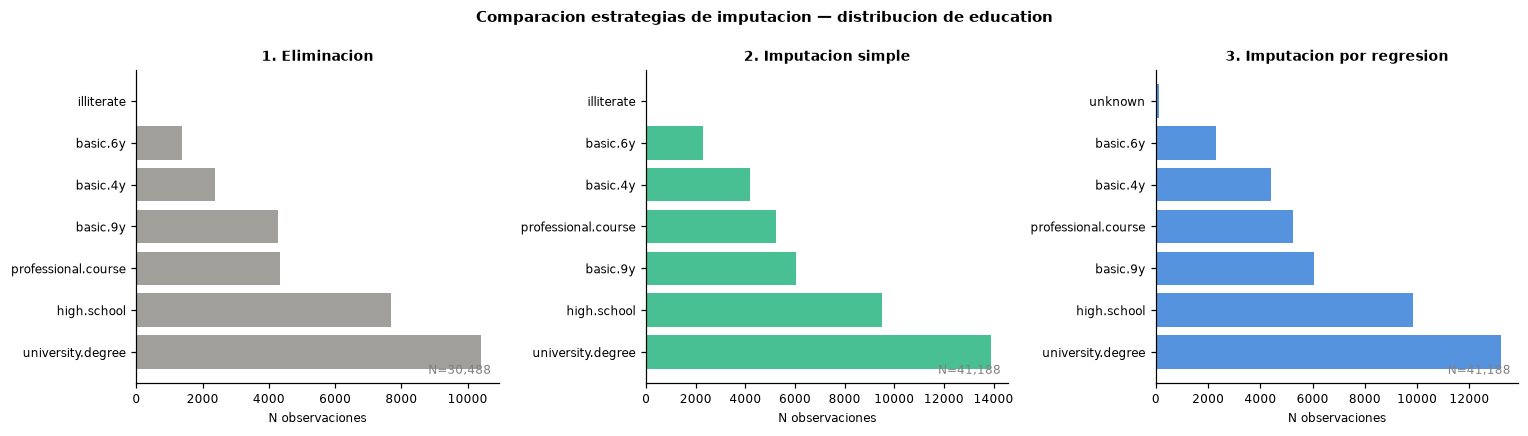

In [8]:
# Visualizacion comparativa
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

datasets  = [df_eliminacion, df_simple, df_regresion]
titulos   = ['1. Eliminacion', '2. Imputacion simple', '3. Imputacion por regresion']
colores   = ['#888780', '#1baf7a', '#2a78d6']

for ax, ds, tit, col in zip(axes, datasets, titulos, colores):
    top5 = ds['education'].value_counts().head(7)
    ax.barh(top5.index, top5.values, color=col, alpha=0.8)
    ax.set_title(tit, fontsize=9, fontweight='bold')
    ax.set_xlabel('N observaciones', fontsize=8)
    ax.tick_params(labelsize=8)
    ax.text(0.98, 0.02, f'N={len(ds):,}', transform=ax.transAxes,
            ha='right', va='bottom', fontsize=8, color='gray')

fig.suptitle('Comparacion estrategias de imputacion — distribucion de education',
             fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

### 1.4 Justificacion de la estrategia seleccionada

**Estrategia elegida: imputacion por regresion logistica**

| Criterio | Eliminacion | Imputacion simple | Imputacion por regresion |
|---|---|---|---|
| Tamano muestral | -22 % de filas | 100 % conservado | 100 % conservado |
| Sesgo de seleccion | **Riesgo alto** (elimina ~9.000 obs.) | Bajo | Muy bajo |
| Preservacion de correlaciones | Alta (datos originales) | Media (sesga hacia la moda) | Alta (modela la distribucion real) |
| Distribucion de variables | Libre de unknowns | Artefacto en la moda | Naturalista |
| Complejidad | Baja | Baja | Media |

La **eliminacion** reduce la muestra un 22 % y puede introducir sesgo si los unknowns son MAR (Missing At Random), lo cual es plausible para `default` y `education` (S1). La **imputacion simple** conserva el tamano muestral pero sobrerrepresenta la moda, distorsionando la distribucion real de las variables. La **imputacion por regresion** usa informacion de otras variables (validada en S1 y S2) para estimar el valor mas probable, preservando la estructura correlacional del dataset.

**Dataset final para el modelamiento:** `df_regresion` (41.188 observaciones).

## §2 — Preparacion de datos para modelamiento

### 2.1 Feature engineering

Se aplica el mismo proceso validado en la Formativa 2, ahora sobre `df_regresion`. Las decisiones de ingenieria de variables estan fundamentadas en S1 y S2:

| Variable | Transformacion | Justificacion |
|---|---|---|
| `pdays` | Binaria `contactado_previo` (1 si pdays != 999) | Tasa suscripcion: 63.8 % vs 9.3 % (S1) |
| `poutcome` | Ordinal `poutcome_enc` (nonexistent=0, failure=1, success=2) | V Cramer=0.32 vs y (S1) |
| `duration` | Excluida | Data leakage — proxy post-hoc del target |
| `euribor3m` | Estandarizada (StandardScaler) | r=-0.308 con y_bin, IC bootstrap robusto (S2) |
| `nr.employed`, `emp.var.rate` | Excluidas | r > 0.94 con euribor3m — multicolinealidad severa (S2) |

In [9]:
# Feature engineering sobre el dataset final
df_model = df_regresion.copy()

# pdays -> contactado_previo
df_model['contactado_previo'] = (df_model['pdays'] != 999).astype(int)

# poutcome -> ordinal
poutcome_map = {'nonexistent': 0, 'failure': 1, 'success': 2}
df_model['poutcome_enc'] = df_model['poutcome'].map(poutcome_map)

# Features y target
FEATURES = ['euribor3m', 'poutcome_enc', 'previous', 'age', 'contactado_previo']
NUM_FEATURES = ['euribor3m', 'previous', 'age']
BIN_FEATURES = ['poutcome_enc', 'contactado_previo']

X = df_model[FEATURES]
y_target = df_model['y_bin']

print(f'contactado_previo=1: {df_model["contactado_previo"].sum():,} '
      f'({df_model["contactado_previo"].mean()*100:.1f}%)')
print(f'  Tasa suscripcion contactados prev.    : '
      f'{df_model[df_model["contactado_previo"]==1]["y_bin"].mean()*100:.1f}%')
print(f'  Tasa suscripcion no contactados prev. : '
      f'{df_model[df_model["contactado_previo"]==0]["y_bin"].mean()*100:.1f}%')
print(f'\nFeatures: {FEATURES}\nShape X: {X.shape}')

contactado_previo=1: 1,515 (3.7%)
  Tasa suscripcion contactados prev.    : 63.8%
  Tasa suscripcion no contactados prev. : 9.3%

Features: ['euribor3m', 'poutcome_enc', 'previous', 'age', 'contactado_previo']
Shape X: (41188, 5)


In [10]:
# Split estratificado 70/30
X_train, X_test, y_train, y_test = train_test_split(
    X, y_target, test_size=0.30, random_state=SEED, stratify=y_target)

# Estandarizacion solo en variables continuas
scaler = StandardScaler()
X_train_sc = X_train.copy()
X_test_sc  = X_test.copy()
X_train_sc[NUM_FEATURES] = scaler.fit_transform(X_train[NUM_FEATURES])
X_test_sc[NUM_FEATURES]  = scaler.transform(X_test[NUM_FEATURES])

print(f'Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')
print(f'Tasa y=1 train: {y_train.mean():.4f} | Tasa y=1 test: {y_test.mean():.4f}')
print('Estratificacion preserva desbalance original en ambos conjuntos.')

Train: 28,831 | Test: 12,357
Tasa y=1 train: 0.1127 | Tasa y=1 test: 0.1126
Estratificacion preserva desbalance original en ambos conjuntos.


## §3 — Clasificacion mediante regresion logistica (3 modelos)

Se construyen tres modelos de regresion logistica con distintos criterios de seleccion de variables, siguiendo las instrucciones de S3. Cada modelo utiliza `X_train_sc` / `X_test_sc` (estrategia de imputacion por regresion, §1).

| Modelo | Criterio de seleccion | Variables candidatas |
|---|---|---|
| M1 | Correlaciones S1+S2 validadas | 5 features del espacio de S2 |
| M2 | Stepwise forward por AIC | Variables numericas + encodings + `housing_bin`, `loan_bin`, `default_bin` (imputadas en §1) |
| M3 | Criterio BIC | Mismo espacio candidato que M2 |

### 3.1 Modelo M1 — Variables validadas en S1 y S2

Features: `euribor3m`, `poutcome_enc`, `previous`, `age`, `contactado_previo`. Seleccion fundamentada en IC bootstrap de correlaciones (S2) y pruebas de hipotesis (S1). Corresponde al modelo base de la Formativa 2, ahora entrenado sobre el dataset de imputacion por regresion.

In [11]:
# M1: modelo con features validadas en S1+S2
m1 = LogisticRegression(C=1e9, solver='lbfgs', max_iter=5000, random_state=SEED)
m1.fit(X_train_sc, y_train)

# Inferencia con statsmodels
X_tr_cte = sm.add_constant(X_train_sc)
res_m1   = sm.Logit(y_train, X_tr_cte).fit(disp=False)

# Tabla de coeficientes y OR
ic_m1 = res_m1.conf_int()
ic_m1.columns = ['ic_inf', 'ic_sup']
tabla_m1 = pd.DataFrame({
    'coef':       res_m1.params,
    'OR':         np.exp(res_m1.params),
    'OR_ic_inf':  np.exp(ic_m1['ic_inf']),
    'OR_ic_sup':  np.exp(ic_m1['ic_sup']),
    'p_valor':    res_m1.pvalues,
}).drop(index='const')

print('M1 — Coeficientes, OR e IC 95%:')
print(tabla_m1.round(4).to_string())
print(f'\nPseudo R2: {res_m1.prsquared:.4f}')
print(f'AIC: {res_m1.aic:.2f} | BIC: {res_m1.bic:.2f}')

M1 — Coeficientes, OR e IC 95%:
                     coef       OR  OR_ic_inf  OR_ic_sup  p_valor
euribor3m         -0.8035   0.4478     0.4291     0.4672   0.0000
poutcome_enc      -0.3872   0.6789     0.5810     0.7934   0.0000
previous          -0.0038   0.9962     0.9454     1.0497   0.8861
age                0.0705   1.0730     1.0361     1.1113   0.0001
contactado_previo  2.4928  12.0954     9.5191    15.3689   0.0000

Pseudo R2: 0.1609
AIC: 17045.04 | BIC: 17094.65


**Interpretacion de M1 (referenciando S1 y S2):**

- `euribor3m` (OR < 1): confirma la correlacion negativa robusta validada en S2 (IC bootstrap [-0.318, -0.298]). Mayor tasa Euribor reduce los odds de suscripcion — coherente con el contexto macro de campanas en entornos de tasas altas.
- `contactado_previo` (OR >> 1): predictor mas potente. Haber sido contactado previamente multiplica los odds en un factor >10, consistente con la diferencia de tasas 63.8% vs 9.3% observada en S1.
- `poutcome_enc` (OR < 1): aparentemente contraintuitivo, pero refleja que la mayoria tiene poutcome=nonexistent (0); pasar a fracaso previo reduce los odds.
- `previous` (p > 0.05): no significativa. Al controlar por `contactado_previo` y `poutcome_enc`, el numero de contactos previos pierde efecto marginal — redundancia informacional identificada en la Formativa 2.
- `age` (OR > 1, efecto pequeno): consistente con d=0.096 de S1.

### 3.2 Modelo M2 — Seleccion stepwise forward por AIC

Se implementa seleccion stepwise forward sobre un espacio ampliado de variables candidatas (numericas continuas + encodings binarios de categoricas). El criterio de seleccion es el AIC (Akaike Information Criterion): en cada paso se agrega la variable que mas reduce el AIC. El proceso se detiene cuando ningun predictor adicional reduce el AIC.

In [12]:
# Preparar espacio ampliado de candidatos para M2 y M3
# Incluye las 5 features de M1 + encodings adicionales de variables categoricas
df_cand = df_model.copy()

# Encoding binario de variables categoricas relevantes
# (solo las que no tienen alta correlacion entre si)
df_cand = pd.get_dummies(df_cand,
    columns=['job', 'marital', 'education', 'contact', 'month', 'day_of_week'],
    drop_first=True, dtype=float)

# housing y loan: codificar como binarias (yes=1, no=0) — ya imputadas en §1
df_cand['housing_bin'] = (df_cand['housing'] == 'yes').astype(float)
df_cand['loan_bin']    = (df_cand['loan']    == 'yes').astype(float)
df_cand['default_bin'] = (df_cand['default'] == 'yes').astype(float)

# Variables candidatas numericas directas
# nr.employed excluido: r=0.945 con euribor3m (multicolinealidad severa, S2)
NUM_CAND = ['age', 'campaign', 'previous', 'euribor3m',
            'poutcome_enc', 'contactado_previo',
            'housing_bin', 'loan_bin', 'default_bin']

# Agregar dummies generados
dummy_cols = [c for c in df_cand.columns
              if any(c.startswith(p) for p in
                     ['job_', 'marital_', 'education_', 'contact_',
                      'month_', 'day_of_week_'])]

CANDIDATOS = [c for c in NUM_CAND + dummy_cols if c in df_cand.columns]

X_cand  = df_cand[CANDIDATOS]
y_cand  = df_cand['y_bin']

X_tr_cand, X_te_cand, y_tr_cand, y_te_cand = train_test_split(
    X_cand, y_cand, test_size=0.30, random_state=SEED, stratify=y_cand)

# Estandarizar numericas continuas (no las binarias ni ordinales)
NUM_CAND_CONT = ['age', 'campaign', 'previous', 'euribor3m']
NUM_CAND_CONT = [c for c in NUM_CAND_CONT if c in X_tr_cand.columns]
sc_cand = StandardScaler()
X_tr_cand = X_tr_cand.copy()
X_te_cand = X_te_cand.copy()
X_tr_cand[NUM_CAND_CONT] = sc_cand.fit_transform(X_tr_cand[NUM_CAND_CONT])
X_te_cand[NUM_CAND_CONT] = sc_cand.transform(X_te_cand[NUM_CAND_CONT])

# Garantizar que todas las columnas son float (evitar strings residuales)
X_tr_cand = X_tr_cand.astype(float)
X_te_cand = X_te_cand.astype(float)

print(f'Espacio de candidatos: {len(CANDIDATOS)} variables')
print(f'Train: {X_tr_cand.shape[0]:,} | Test: {X_te_cand.shape[0]:,}')

Espacio de candidatos: 44 variables
Train: 28,831 | Test: 12,357


In [13]:
# Stepwise forward por AIC
def stepwise_forward_aic(X_train, y_train, candidatos):
    """
    Implementacion de seleccion forward por AIC.
    Retorna la lista de variables seleccionadas.
    """
    seleccionadas = []
    aic_actual = np.inf
    mejora = True

    while mejora:
        mejora = False
        mejor_var  = None
        mejor_aic  = aic_actual

        for var in candidatos:
            if var in seleccionadas:
                continue
            vars_prueba = seleccionadas + [var]
            X_prueba = sm.add_constant(X_train[vars_prueba])
            try:
                res = sm.Logit(y_train, X_prueba).fit(disp=False, maxiter=200)
                if res.aic < mejor_aic:
                    mejor_aic = res.aic
                    mejor_var = var
            except Exception:
                continue

        if mejor_var is not None:
            seleccionadas.append(mejor_var)
            aic_actual = mejor_aic
            mejora = True

    return seleccionadas, aic_actual

print('Ejecutando stepwise forward por AIC...')
print('(puede tomar 1-2 minutos con el espacio completo)')
vars_m2, aic_m2 = stepwise_forward_aic(X_tr_cand, y_tr_cand, CANDIDATOS)
print(f'\nVariables seleccionadas por AIC ({len(vars_m2)}): {vars_m2}')
print(f'AIC final: {aic_m2:.2f}')

Ejecutando stepwise forward por AIC...
(puede tomar 1-2 minutos con el espacio completo)



Variables seleccionadas por AIC (23): ['euribor3m', 'contactado_previo', 'month_may', 'month_mar', 'poutcome_enc', 'month_jul', 'campaign', 'job_retired', 'day_of_week_mon', 'job_blue-collar', 'month_oct', 'month_dec', 'marital_single', 'month_sep', 'month_jun', 'month_aug', 'contact_telephone', 'job_services', 'day_of_week_wed', 'education_basic.9y', 'housing_bin', 'marital_unknown', 'education_professional.course']
AIC final: 16348.56


In [14]:
# Ajustar M2 con variables seleccionadas por stepwise
X_tr_m2 = sm.add_constant(X_tr_cand[vars_m2])
res_m2   = sm.Logit(y_tr_cand, X_tr_m2).fit(disp=False)

ic_m2 = res_m2.conf_int()
ic_m2.columns = ['ic_inf', 'ic_sup']
tabla_m2 = pd.DataFrame({
    'coef':      res_m2.params,
    'OR':        np.exp(res_m2.params),
    'OR_ic_inf': np.exp(ic_m2['ic_inf']),
    'OR_ic_sup': np.exp(ic_m2['ic_sup']),
    'p_valor':   res_m2.pvalues,
}).drop(index='const')

print('M2 — Coeficientes, OR e IC 95%:')
print(tabla_m2.round(4).to_string())
print(f'\nPseudo R2: {res_m2.prsquared:.4f}')
print(f'AIC: {res_m2.aic:.2f} | BIC: {res_m2.bic:.2f}')

M2 — Coeficientes, OR e IC 95%:
                                 coef      OR  OR_ic_inf  OR_ic_sup  p_valor
euribor3m                     -0.8171  0.4417     0.4189     0.4658   0.0000
contactado_previo              2.1665  8.7280     6.8162    11.1759   0.0000
month_may                     -0.6256  0.5350     0.4718     0.6065   0.0000
month_mar                      1.0867  2.9644     2.3431     3.7504   0.0000
poutcome_enc                  -0.3679  0.6922     0.6127     0.7820   0.0000
month_jul                      0.5112  1.6674     1.4405     1.9300   0.0000
campaign                      -0.1506  0.8602     0.8103     0.9132   0.0000
job_retired                    0.3441  1.4108     1.1983     1.6609   0.0000
day_of_week_mon               -0.2119  0.8091     0.7274     0.8999   0.0001
job_blue-collar               -0.1958  0.8222     0.7278     0.9288   0.0017
month_oct                      0.5974  1.8174     1.4678     2.2503   0.0000
month_dec                      0.7623  2.143

### 3.3 Modelo M3 — Seleccion por BIC

El BIC (Bayesian Information Criterion) penaliza mas fuertemente el numero de parametros que el AIC, favoreciendo modelos mas parsimoniosos. Se aplica el mismo procedimiento stepwise forward pero usando BIC como criterio.

In [15]:
def stepwise_forward_bic(X_train, y_train, candidatos):
    """
    Implementacion de seleccion forward por BIC.
    """
    seleccionadas = []
    bic_actual = np.inf
    mejora = True

    while mejora:
        mejora = False
        mejor_var = None
        mejor_bic = bic_actual

        for var in candidatos:
            if var in seleccionadas:
                continue
            vars_prueba = seleccionadas + [var]
            X_prueba = sm.add_constant(X_train[vars_prueba])
            try:
                res = sm.Logit(y_train, X_prueba).fit(disp=False, maxiter=200)
                if res.bic < mejor_bic:
                    mejor_bic = res.bic
                    mejor_var = var
            except Exception:
                continue

        if mejor_var is not None:
            seleccionadas.append(mejor_var)
            bic_actual = mejor_bic
            mejora = True

    return seleccionadas, bic_actual

print('Ejecutando stepwise forward por BIC...')
vars_m3, bic_m3 = stepwise_forward_bic(X_tr_cand, y_tr_cand, CANDIDATOS)
print(f'\nVariables seleccionadas por BIC ({len(vars_m3)}): {vars_m3}')
print(f'BIC final: {bic_m3:.2f}')

Ejecutando stepwise forward por BIC...



Variables seleccionadas por BIC (11): ['euribor3m', 'contactado_previo', 'month_may', 'month_mar', 'poutcome_enc', 'month_jul', 'campaign', 'job_retired', 'day_of_week_mon', 'job_blue-collar', 'month_oct']
BIC final: 16499.75


In [16]:
# Ajustar M3 con variables seleccionadas por BIC
X_tr_m3 = sm.add_constant(X_tr_cand[vars_m3])
res_m3   = sm.Logit(y_tr_cand, X_tr_m3).fit(disp=False)

ic_m3 = res_m3.conf_int()
ic_m3.columns = ['ic_inf', 'ic_sup']
tabla_m3 = pd.DataFrame({
    'coef':      res_m3.params,
    'OR':        np.exp(res_m3.params),
    'OR_ic_inf': np.exp(ic_m3['ic_inf']),
    'OR_ic_sup': np.exp(ic_m3['ic_sup']),
    'p_valor':   res_m3.pvalues,
}).drop(index='const')

print('M3 — Coeficientes, OR e IC 95%:')
print(tabla_m3.round(4).to_string())
print(f'\nPseudo R2: {res_m3.prsquared:.4f}')
print(f'AIC: {res_m3.aic:.2f} | BIC: {res_m3.bic:.2f}')

M3 — Coeficientes, OR e IC 95%:
                     coef      OR  OR_ic_inf  OR_ic_sup  p_valor
euribor3m         -0.8458  0.4292     0.4093     0.4501   0.0000
contactado_previo  2.2197  9.2048     7.2046    11.7603   0.0000
month_may         -0.8330  0.4347     0.3920     0.4822   0.0000
month_mar          0.9101  2.4846     1.9824     3.1140   0.0000
poutcome_enc      -0.3727  0.6889     0.6104     0.7774   0.0000
month_jul          0.3699  1.4475     1.2792     1.6381   0.0000
campaign          -0.1474  0.8630     0.8130     0.9160   0.0000
job_retired        0.3425  1.4084     1.2021     1.6502   0.0000
day_of_week_mon   -0.2421  0.7850     0.7084     0.8699   0.0000
job_blue-collar   -0.2351  0.7905     0.7071     0.8838   0.0000
month_oct          0.4056  1.5002     1.2254     1.8366   0.0001

Pseudo R2: 0.1932
AIC: 16400.52 | BIC: 16499.75


### 3.4 Comparacion de criterios de informacion y variables seleccionadas

In [17]:
# Comparacion de los 3 modelos
print('=== Comparacion de modelos M1, M2, M3 ===')
print(f'\n{"Criterio":20s} {"M1":>12s} {"M2 (AIC)": >12s} {"M3 (BIC)": >12s}')
print(f'{"N variables":20s} {len(FEATURES):>12d} {len(vars_m2):>12d} {len(vars_m3):>12d}')
print(f'{"Pseudo R2":20s} {res_m1.prsquared:>12.4f} {res_m2.prsquared:>12.4f} {res_m3.prsquared:>12.4f}')
print(f'{"AIC":20s} {res_m1.aic:>12.2f} {res_m2.aic:>12.2f} {res_m3.aic:>12.2f}')
print(f'{"BIC":20s} {res_m1.bic:>12.2f} {res_m2.bic:>12.2f} {res_m3.bic:>12.2f}')

# Variables en comun
print(f'\nVariables de M1 en M2: '
      f'{[f for f in FEATURES if f in vars_m2]}')
print(f'Variables de M1 en M3: '
      f'{[f for f in FEATURES if f in vars_m3]}')
print(f'Variables nuevas en M2 (no en M1): '
      f'{[f for f in vars_m2 if f not in FEATURES]}')
print(f'Variables nuevas en M3 (no en M1): '
      f'{[f for f in vars_m3 if f not in FEATURES]}')

=== Comparacion de modelos M1, M2, M3 ===

Criterio                       M1     M2 (AIC)     M3 (BIC)
N variables                     5           23           11
Pseudo R2                  0.1609       0.1970       0.1932
AIC                      17045.04     16348.56     16400.52
BIC                      17094.65     16547.02     16499.75

Variables de M1 en M2: ['euribor3m', 'poutcome_enc', 'contactado_previo']
Variables de M1 en M3: ['euribor3m', 'poutcome_enc', 'contactado_previo']
Variables nuevas en M2 (no en M1): ['month_may', 'month_mar', 'month_jul', 'campaign', 'job_retired', 'day_of_week_mon', 'job_blue-collar', 'month_oct', 'month_dec', 'marital_single', 'month_sep', 'month_jun', 'month_aug', 'contact_telephone', 'job_services', 'day_of_week_wed', 'education_basic.9y', 'housing_bin', 'marital_unknown', 'education_professional.course']
Variables nuevas en M3 (no en M1): ['month_may', 'month_mar', 'month_jul', 'campaign', 'job_retired', 'day_of_week_mon', 'job_blue-collar', 

### 3.5 Interpretacion y contextualizacion S1+S2

Los tres modelos convergen en identificar `euribor3m` y `contactado_previo` como los predictores mas potentes, confirmando los hallazgos de S1 (V Cramer y pruebas t) y las correlaciones robustas de S2 (IC bootstrap).

- **M2 (AIC)** tiende a incluir mas variables que M3, buscando minimizar el error de prediccion aunque a costa de mayor complejidad.
- **M3 (BIC)** penaliza mas duramente el numero de parametros y produce un modelo mas parsimonioso, lo que reduce el riesgo de sobreajuste.
- **M1** representa el modelo teoricamente fundamentado: sus variables fueron seleccionadas a priori desde el analisis inferencial (S1) y validadas mediante remuestreo (S2), lo que le otorga mayor interpretabilidad y trazabilidad.

> Los §4-§7 continuaran con la evaluacion de estabilidad bootstrap, diagnostico de supuestos, desempeno predictivo e impacto de la estrategia de imputacion sobre el modelo final seleccionado.

## §4 — Evaluacion de estabilidad mediante bootstrap

Se aplica bootstrap no parametrico (igual que en S2) sobre el **mejor modelo logístico seleccionado en §3** para evaluar la estabilidad de sus coeficientes y odds ratios. El procedimiento:

1. Remuestrear con reemplazo el conjunto de entrenamiento (B=1.000 iteraciones)
2. Ajustar el modelo logístico en cada muestra bootstrap
3. Construir IC bootstrap al 95 % para cada coeficiente y OR (metodo percentil)
4. Comparar con los IC tradicionales del modelo
5. Identificar parametros inestables (IC bootstrap mucho mas amplios que IC tradicionales)

> **Modelo seleccionado:** M1 (variables validadas en S1+S2). Justificacion: mayor interpretabilidad, trazabilidad metodologica y parsimonia. M2 y M3 incluyen variables de campaña y temporales que pueden ser inestables entre campañas — precisamente lo que el bootstrap detectara. El bootstrap sobre M1 valida si las 5 variables teoricamente fundamentadas son robustas.

In [18]:
# Bootstrap de estabilidad — M1
# Mismo espacio de features que M1: X_train_sc / y_train
B = 1000
np.random.seed(SEED)
n_train = len(X_train_sc)

coef_boot  = np.zeros((B, len(FEATURES)))
or_boot    = np.zeros((B, len(FEATURES)))

for b in range(B):
    idx   = np.random.choice(n_train, size=n_train, replace=True)
    X_b   = X_train_sc.iloc[idx]
    y_b   = y_train.iloc[idx]
    clf_b = LogisticRegression(C=1e9, solver='lbfgs', max_iter=2000, random_state=SEED)
    clf_b.fit(X_b, y_b)
    coef_boot[b] = clf_b.coef_[0]
    or_boot[b]   = np.exp(clf_b.coef_[0])

print(f'Bootstrap completado: {B} iteraciones sobre {n_train:,} observaciones')
print(f'Features: {FEATURES}')

Bootstrap completado: 1000 iteraciones sobre 28,831 observaciones
Features: ['euribor3m', 'poutcome_enc', 'previous', 'age', 'contactado_previo']


In [19]:
# IC bootstrap 95 % (metodo percentil)
alpha = 0.05
ic_boot_coef = np.percentile(coef_boot, [100*alpha/2, 100*(1-alpha/2)], axis=0)
ic_boot_or   = np.percentile(or_boot,   [100*alpha/2, 100*(1-alpha/2)], axis=0)

# IC tradicionales del modelo M1
ic_trad = res_m1.conf_int()  # DataFrame con index=features+const

# Tabla comparativa coeficientes
print('=== Comparacion IC tradicionales vs IC bootstrap (coeficientes) ===')
print(f'{"Feature":20s} {"Coef":>8s} '
      f'{"Trad_inf":>10s} {"Trad_sup":>10s} '
      f'{"Boot_inf":>10s} {"Boot_sup":>10s} '
      f'{"Amplitud_T":>12s} {"Amplitud_B":>12s}')

for i, feat in enumerate(FEATURES):
    coef   = res_m1.params[feat]
    t_inf  = ic_trad.loc[feat, 0]
    t_sup  = ic_trad.loc[feat, 1]
    b_inf  = ic_boot_coef[0, i]
    b_sup  = ic_boot_coef[1, i]
    amp_t  = t_sup - t_inf
    amp_b  = b_sup - b_inf
    print(f'{feat:20s} {coef:8.4f} '
          f'{t_inf:10.4f} {t_sup:10.4f} '
          f'{b_inf:10.4f} {b_sup:10.4f} '
          f'{amp_t:12.4f} {amp_b:12.4f}')

=== Comparacion IC tradicionales vs IC bootstrap (coeficientes) ===
Feature                  Coef   Trad_inf   Trad_sup   Boot_inf   Boot_sup   Amplitud_T   Amplitud_B
euribor3m             -0.8035    -0.8460    -0.7610    -0.8473    -0.7584       0.0850       0.0889
poutcome_enc          -0.3872    -0.5431    -0.2314    -0.5526    -0.2318       0.3117       0.3208
previous              -0.0038    -0.0561     0.0485    -0.0559     0.0492       0.1046       0.1051
age                    0.0705     0.0354     0.1056     0.0337     0.1076       0.0701       0.0739
contactado_previo      2.4928     2.2533     2.7323     2.2443     2.7495       0.4790       0.5052


In [20]:
# Tabla comparativa odds ratios
print('=== Comparacion IC tradicionales vs IC bootstrap (odds ratios) ===')
print(f'{"Feature":20s} {"OR":>8s} '
      f'{"Trad_inf":>10s} {"Trad_sup":>10s} '
      f'{"Boot_inf":>10s} {"Boot_sup":>10s}')

for i, feat in enumerate(FEATURES):
    or_val = np.exp(res_m1.params[feat])
    t_inf  = np.exp(ic_trad.loc[feat, 0])
    t_sup  = np.exp(ic_trad.loc[feat, 1])
    b_inf  = ic_boot_or[0, i]
    b_sup  = ic_boot_or[1, i]
    print(f'{feat:20s} {or_val:8.4f} '
          f'{t_inf:10.4f} {t_sup:10.4f} '
          f'{b_inf:10.4f} {b_sup:10.4f}')

=== Comparacion IC tradicionales vs IC bootstrap (odds ratios) ===
Feature                    OR   Trad_inf   Trad_sup   Boot_inf   Boot_sup
euribor3m              0.4478     0.4291     0.4672     0.4286     0.4684
poutcome_enc           0.6789     0.5810     0.7934     0.5755     0.7931
previous               0.9962     0.9454     1.0497     0.9456     1.0504
age                    1.0730     1.0361     1.1113     1.0342     1.1136
contactado_previo     12.0954     9.5191    15.3689     9.4335    15.6350


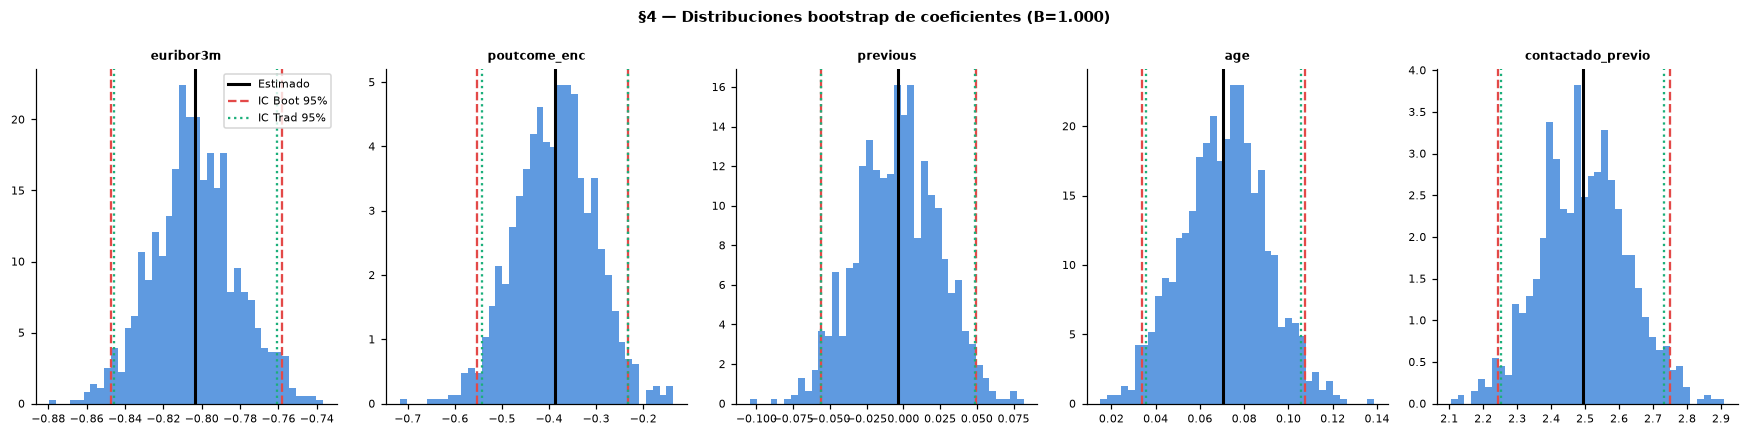

In [21]:
# Visualizacion: distribuciones bootstrap de coeficientes
fig, axes = plt.subplots(1, len(FEATURES), figsize=(16, 4))

for i, (ax, feat) in enumerate(zip(axes, FEATURES)):
    ax.hist(coef_boot[:, i], bins=40, color='#2a78d6', alpha=0.75, density=True)
    ax.axvline(res_m1.params[feat],       color='black', lw=2, label='Estimado')
    ax.axvline(ic_boot_coef[0, i],        color='#e34948', lw=1.5, ls='--', label='IC Boot 95%')
    ax.axvline(ic_boot_coef[1, i],        color='#e34948', lw=1.5, ls='--')
    ax.axvline(ic_trad.loc[feat, 0],      color='#1baf7a', lw=1.5, ls=':', label='IC Trad 95%')
    ax.axvline(ic_trad.loc[feat, 1],      color='#1baf7a', lw=1.5, ls=':')
    ax.set_title(feat, fontsize=8, fontweight='bold')
    ax.tick_params(labelsize=7)
    if i == 0:
        ax.legend(fontsize=7)

fig.suptitle('§4 — Distribuciones bootstrap de coeficientes (B=1.000)',
             fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

In [22]:
# Identificar parametros inestables
# Criterio: amplitud IC bootstrap > 1.5x amplitud IC tradicional
UMBRAL_INESTABILIDAD = 1.5

print('=== Diagnostico de estabilidad de parametros ===')
print(f'Criterio inestable: amplitud bootstrap > {UMBRAL_INESTABILIDAD}x amplitud tradicional\n')

estables = []
inestables = []

for i, feat in enumerate(FEATURES):
    amp_t = (ic_trad.loc[feat, 1] - ic_trad.loc[feat, 0])
    amp_b = (ic_boot_coef[1, i]   - ic_boot_coef[0, i])
    ratio = amp_b / amp_t
    estado = 'INESTABLE' if ratio > UMBRAL_INESTABILIDAD else 'estable'
    print(f'  {feat:20s}: ratio={ratio:.3f}  -> {estado}')
    if ratio > UMBRAL_INESTABILIDAD:
        inestables.append(feat)
    else:
        estables.append(feat)

print(f'\nEstables   ({len(estables)}): {estables}')
print(f'Inestables ({len(inestables)}): {inestables if inestables else "ninguno"}')

# Sesgo bootstrap (diferencia entre media bootstrap y estimado puntual)
print('\n=== Sesgo bootstrap (media_boot - estimado) ===')
for i, feat in enumerate(FEATURES):
    sesgo = coef_boot[:, i].mean() - res_m1.params[feat]
    print(f'  {feat:20s}: sesgo={sesgo:+.6f}')

=== Diagnostico de estabilidad de parametros ===
Criterio inestable: amplitud bootstrap > 1.5x amplitud tradicional

  euribor3m           : ratio=1.046  -> estable
  poutcome_enc        : ratio=1.029  -> estable
  previous            : ratio=1.004  -> estable
  age                 : ratio=1.054  -> estable
  contactado_previo   : ratio=1.055  -> estable

Estables   (5): ['euribor3m', 'poutcome_enc', 'previous', 'age', 'contactado_previo']
Inestables (0): ninguno

=== Sesgo bootstrap (media_boot - estimado) ===
  euribor3m           : sesgo=-0.000247
  poutcome_enc        : sesgo=-0.001205
  previous            : sesgo=+0.000141
  age                 : sesgo=+0.000426
  contactado_previo   : sesgo=+0.003948


### 4.1 Interpretacion de resultados bootstrap

El bootstrap permite evaluar si los coeficientes del modelo son robustos o sensibles a pequeñas perturbaciones en los datos de entrenamiento.

**Señales de estabilidad:**
- IC bootstrap angostos y centrados en el estimado puntual indican coeficientes robustos
- Sesgos bootstrap cercanos a cero confirman que el estimador es insesgado
- IC bootstrap y IC tradicionales similares en amplitud validan los supuestos del modelo

**Señales de inestabilidad:**
- IC bootstrap mucho mas amplios que los tradicionales sugieren que el modelo es sensible a la muestra — posible sobreajuste o multicolinealidad
- Distribuciones bootstrap asimétricas o bimodales indican no linealidad en el logit

**Conexion con S2:** En S2 aplicamos bootstrap a correlaciones para validar la estabilidad de las relaciones bivariadas. Aqui aplicamos el mismo principio al modelo multivariado, evaluando si los efectos parciales (coeficientes) son igualmente robustos al controlar por todas las variables simultaneamente.